# CYGNSS Streamflow Modeling for Ungauged Basins (CSMUB)

## Feedforward Neural Network (FNN) Model

### About

This code

---


Author(s): Anna Valcarcel

Date of Creation: November 15, 2024

Last Updated: November 11, 2025

Version History:
*   v1.00:06 - Creating FNN architecture and running model. Modulating architecture and input parameters.
*   v1.07:09 - Added additional input parameters including land cover classification, soil texture, and terrain slope.

*   v2.00 - Re-running with new subset of all basins (605) after making delineation changes (see `CSMUB_v2_00`). 

## Importing Packages

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report

from tensorflow.python import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN , Input, Flatten, LSTM, LeakyReLU
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import SGD, RMSprop, Nadam, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

## Define Filepaths and Open Station Masterfile


In [2]:
opened = []

masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS_ALL_DAYS_COMBINED.csv'

# Load the master list of stations
total_df = pd.read_csv(masterlist)

/tmp/ipykernel_3297350/1724744278.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  total_df = pd.read_csv(masterlist)


In [3]:
total_df = total_df[total_df['Q'] != -999]
print(f"Remaining rows: {len(total_df)}")

Remaining rows: 844768


In [4]:
print("Loaded ", len(total_df['grdc_no'].unique()), " stations.")

Loaded  563  stations.


## Save Subset for Training

In [5]:
print(total_df.columns)

Index(['Date', 'grdc_no', 'river', 'station', 'country', 'lat', 'long', 'area',
       'area_delin', 'altitude', 'Q', 'SWE', 'SWE_scaled', 'r2', 'P',
       'avg_slope', 'max_slope', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5',
       'LC_6', 'LC_7', 'LC_8', 'LC_9', 'LC_10', 'LC_11', 'LC_12', 'LC_13',
       'LC_14', 'LC_15', 'LC_16', 'LC_17', 'LC_18', 'LC_19', 'LC_20', 'ST_1',
       'ST_2', 'ST_3', 'ST_4', 'ST_5', 'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10',
       'ST_11', 'ST_12', 'ST_13', 'ST_14', 'ST_15', 'ST_16'],
      dtype='object')


In [6]:
training_df = total_df.drop(['Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
       'altitude', 'Q', 'SWE','r2',], axis=1)
test_df = total_df['Q']

print(training_df.columns)
print(test_df)

Index(['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope',
       'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9',
       'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 'LC_16', 'LC_17',
       'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5',
       'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13',
       'ST_14', 'ST_15', 'ST_16'],
      dtype='object')
0         26.393
1         27.602
2         26.674
3         26.687
4         26.988
           ...  
892793    11.757
892794    11.458
892795     9.106
892796     7.894
892797     7.240
Name: Q, Length: 844768, dtype: float64


In [7]:
training_np = training_df.to_numpy()
test_np = test_df.to_numpy()
print(len(training_np))

844768


In [8]:
# q = total_df['Q']
# swe = total_df['SWE']
# scaled = total_df['SWE_scaled']
# area = total_df['area_delin']
# station = total_df['grdc_no']
# lat = total_df['lat']
# avg_slope = total_df['avg_slope']
# max_slope = total_df['max_slope']
# precip = total_df['P']

## FNN Setup

In [9]:
# Step 1: Replace zeros with a small value
training_np[training_np == 0] = 1e-9

# Step 2: Combine features into a 2D array
X = training_np
y = test_np

# Step 3: Scale the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
print(X_scaled[0])
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

[0.10942487 0.397724   0.13106963 0.01182197 0.05308483 0.62523689
 0.07061055 0.60888053 0.18808161 0.04879158 0.0190711  0.02888432
 0.04921768 0.06228898 0.05010108 0.01325509 0.04677467 0.03442118
 0.05320244 0.04953747 0.04023999 0.02505596 0.03384965 0.01038826
 0.         0.         0.         0.09314503 0.47446995 0.02609459
 0.14721127 0.24074771 0.01247766 0.0235117  0.05453931 0.00802911
 0.01993283 0.02170368 0.         0.         0.         0.        ]


In [10]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [11]:
print(len(X_train[0]))

42


## Run FNN

In [12]:
# Define the model
model = Sequential([
    Dense(512, input_dim=42, activation='leaky_relu'),
    # Dense(256, activation='leaky_relu'),
    # Dropout(0.2),
    Dense(128, activation='leaky_relu'),
    Dropout(0.2),
    # Dense(64, activation='leaky_relu'),
    # Dropout(0.2),
    Dense(32, activation='leaky_relu'),
    Dense(1, activation='linear')  # Linear activation for regression
])

# Compile the model
model.compile(optimizer=Nadam(learning_rate=1e-3), loss=Huber(delta=0.1), metrics=['accuracy','mae','mse','r2_score'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=175,  # High epochs with early stopping
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping, lr_scheduler]
)

/global/home/users/arvalcarcel/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-11 23:56:29.459227: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/175
10560/10560 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.0992 - loss: 8.6672e-05 - mae: 0.0048 - mse: 2.3405e-04 - r2_score: 0.7646 - val_accuracy: 0.0987 - val_loss: 5.7734e-05 - val_mae: 0.0039 - val_mse: 1.4140e-04 - val_r2_score: 0.8623 - learning_rate: 0.0010
Epoch 2/175
10560/10560 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.1001 - loss: 5.0444e-05 - mae: 0.0031 - mse: 1.2286e-04 - r2_score: 0.8888 - val_accuracy: 0.0987 - val_loss: 4.5849e-05 - val_mae: 0.0029 - val_mse: 1.0306e-04 - val_r2_score: 0.8996 - learning_rate: 0.0010
Epoch 3/175
10560/10560 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.0999 - loss: 4.4822e-05 - mae: 0.0029 - mse: 1.0814e-04 - r2_score: 0.8967 - val_accuracy: 0.0987 - val_loss: 3.8772e-05 - val_mae: 0.0031 - val_mse: 8.7741e-05 - val_r2_score: 0.9146 - learning_rate: 0.0010
Epoch 4/175
10560/10560 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.0994 - loss: 4.2702e-05 - mae: 0.0029 - mse: 1.0288e-04 - r2_score: 0.9030 - val_accurac

In [ ]:
# Step 7: Evaluate
test_loss = model.evaluate(X_test, y_test)
print(f"Test MAPE: {test_loss}")

# Step 8: Predict
predictions = model.predict(X_test)
y_pred = scaler_y.inverse_transform(predictions)

4282/5280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0988 - loss: 2.4764e-05 - mae: 0.0016 - mse: 5.6812e-05 - r2_score: 0.9451

## 1:1

In [21]:
# Step 7: Evaluate
test_loss = model.evaluate(X_test, y_test)
print(f"Test MAPE: {test_loss}")

# Step 8: Predict
predictions = model.predict(X_test)
y_pred = scaler_y.inverse_transform(predictions)
y_test_unscaled = scaler_y.inverse_transform(y_test)

5280/5280 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.0987 - loss: 2.4703e-05 - mae: 0.0016 - mse: 5.6600e-05 - r2_score: 0.9454
Test MAPE: [2.4360746465390548e-05, 0.09871325641870499, 0.0016089127166196704, 5.5195057939272374e-05, 0.9462464451789856]
5280/5280 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


In [22]:
def nse(predictions, targets):
    return 1 - (np.sum((targets - predictions) ** 2) / np.sum((targets - np.mean(targets)) ** 2))

nse_value = nse(y_pred, y_test_unscaled)
print("NSE:", nse_value)

NSE: 0.9462464310016115


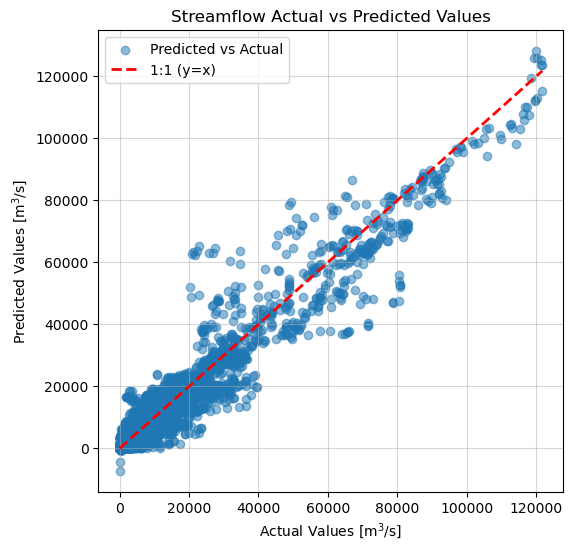

In [23]:
# Step 1: Predict values
# y_pred = model.predict(X_test)
# y_pred = np.expm1(y_pred)

# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_unscaled, y_pred, alpha=0.5, label="Predicted vs Actual")
plt.plot([0, y.max()], [0, y.max()], 'r--', label='1:1 (y=x)', linewidth=2)

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend()
# plt.xlim(0,25000)
# plt.ylim(0,25000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

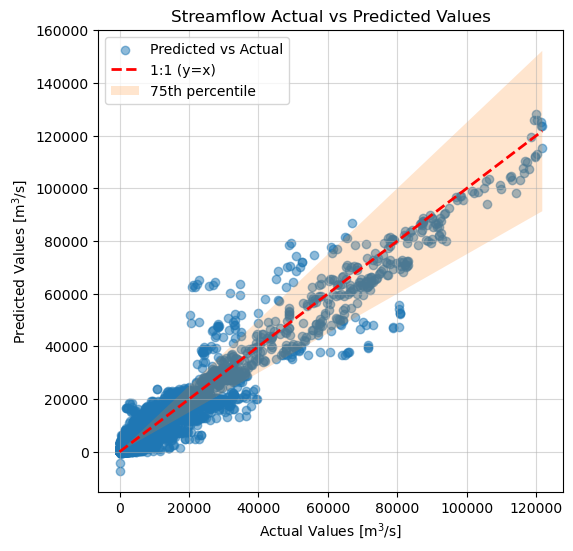

In [24]:
error = 0.25*np.arange(y.min(), y.max(),100)
y_err = np.arange(y.min(), y.max(),100)

# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_unscaled, y_pred, alpha=0.5, label="Predicted vs Actual")
plt.plot([0, y.max()], [0, y.max()], 'r--', label='1:1 (y=x)', linewidth=2)
plt.fill_between(y_err, y_err-error, y_err+error,alpha=0.2,label='75th percentile')

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend(loc='upper left')
# plt.xlim(0,25000)
# plt.ylim(0,25000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

In [25]:
# plt.plot(y_pred[0:200])
# plt.plot(y_test[0:200]*max(y))
# plt.show()

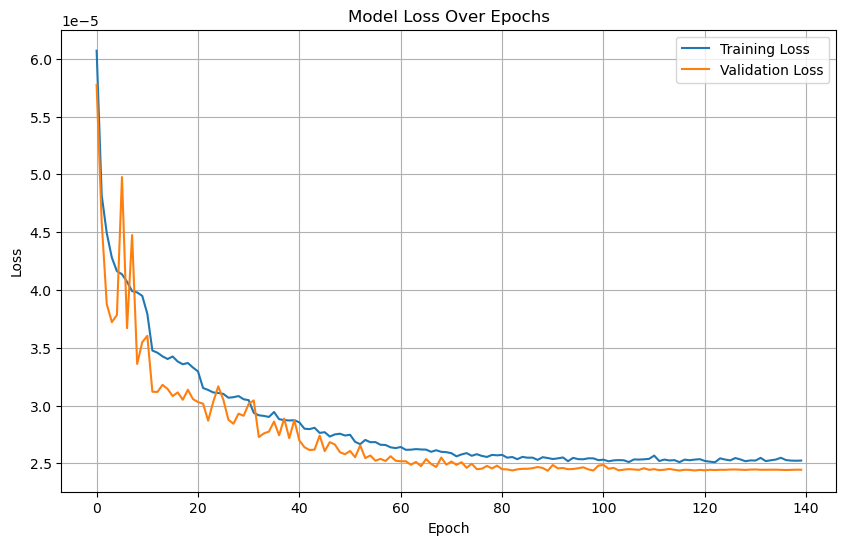

In [30]:
loss = history.history['loss']
val_loss = history.history['val_loss']
# loss_unscaled = scaler_y.inverse_transform(loss)
# val_loss_unscaled = scaler_y.inverse_transform(val_loss)

plt.figure(figsize=(10,6))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# predict on training and validation
train_pred_scaled = model.predict(X_train)
val_pred_scaled   = model.predict(X_test)

# unscale
train_pred = scaler_y.inverse_transform(train_pred_scaled)
val_pred   = scaler_y.inverse_transform(val_pred_scaled)

train_true = scaler_y.inverse_transform(y_train)
val_true   = scaler_y.inverse_transform(y_test)

# compute real-unit losses
mae_train_unscaled = mean_absolute_error(train_true, train_pred)
mae_val_unscaled   = mean_absolute_error(val_true, val_pred)

print("Training MAE (original units):", mae_train_unscaled)
print("Validation MAE (original units):", mae_val_unscaled)

21120/21120 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step
5280/5280 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Training MAE (original units): 195.30984833300505
Validation MAE (original units): 195.80724601214965


## Recreate Timeseries

In [33]:
# Re-create timeseries
station_no = total_df['grdc_no'].unique()
freq_stations = total_df['grdc_no'].value_counts()
print(freq_stations.index[0])

3512025


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


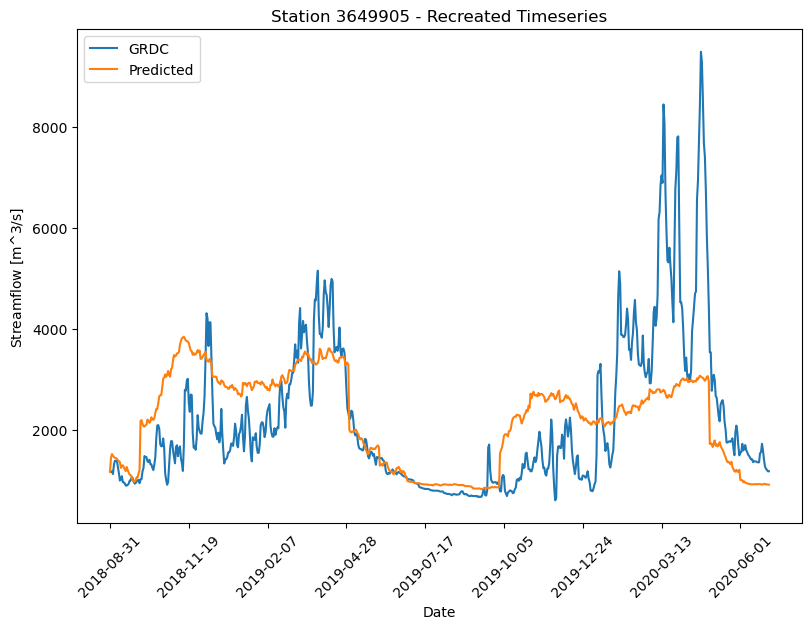

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


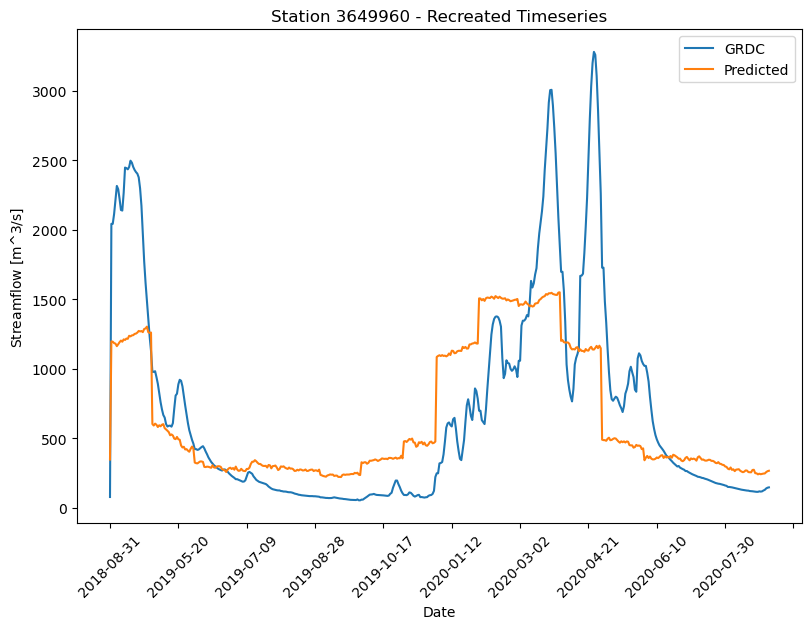

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


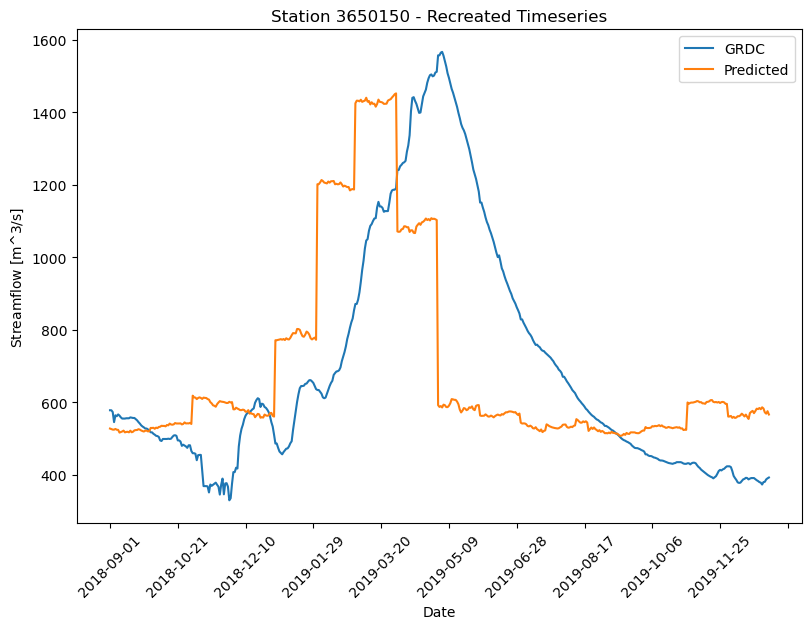

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


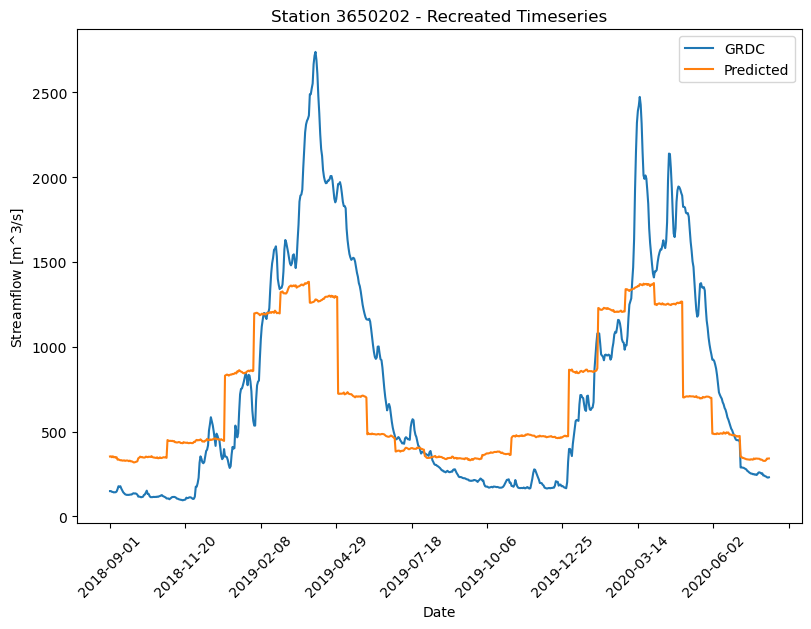

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


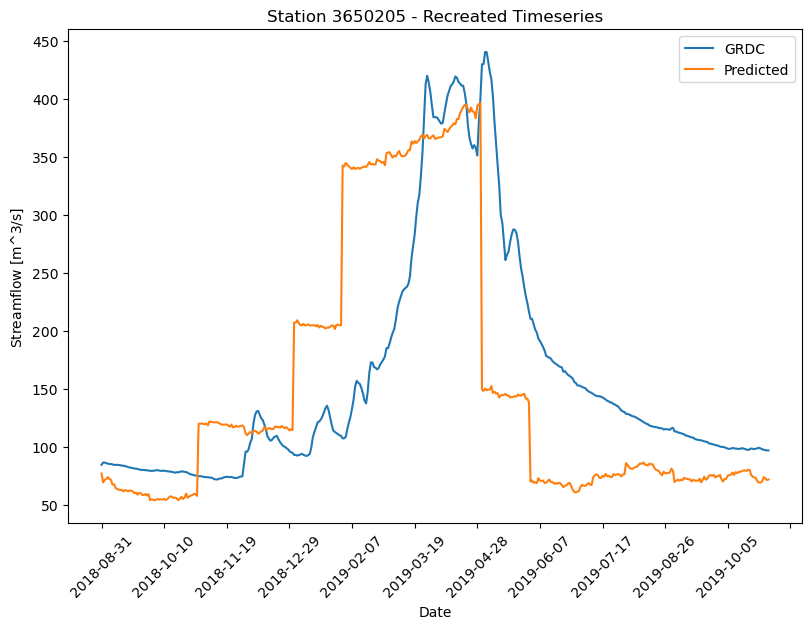

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


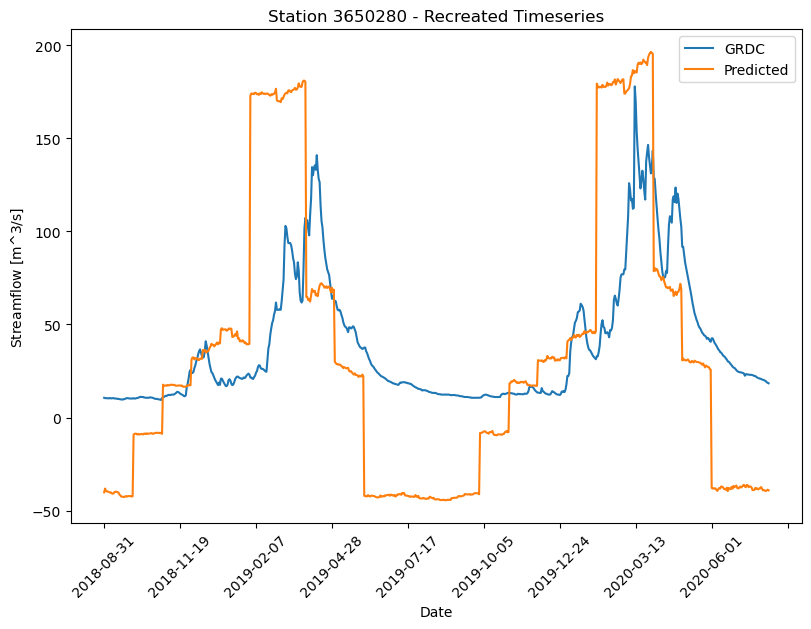

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


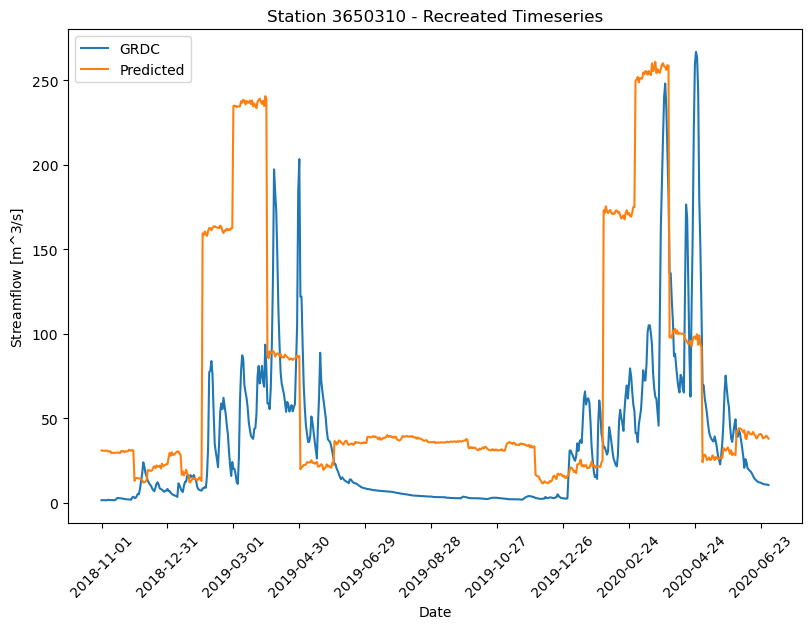

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


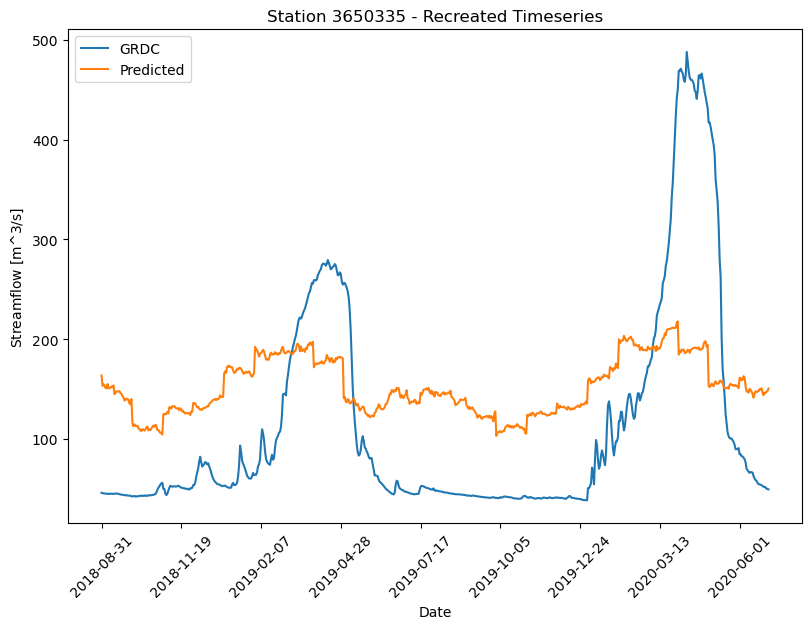

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


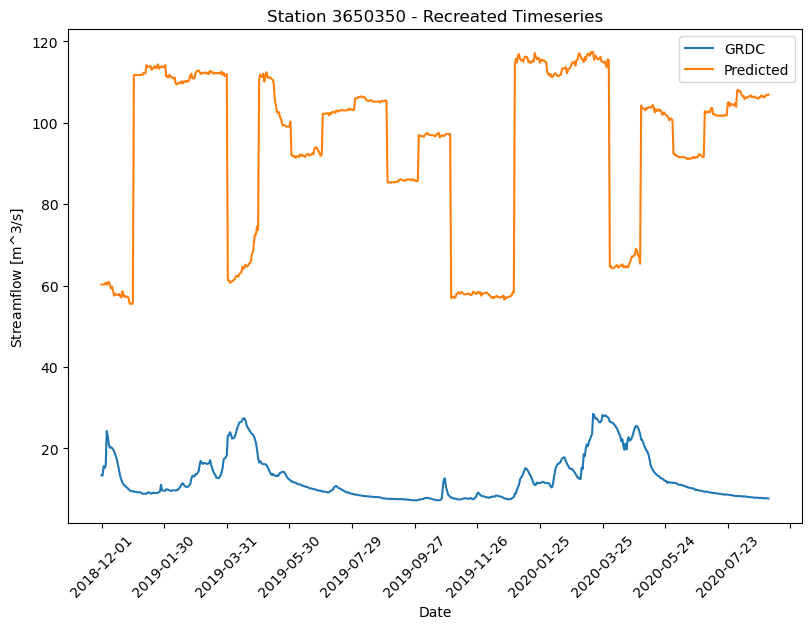

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


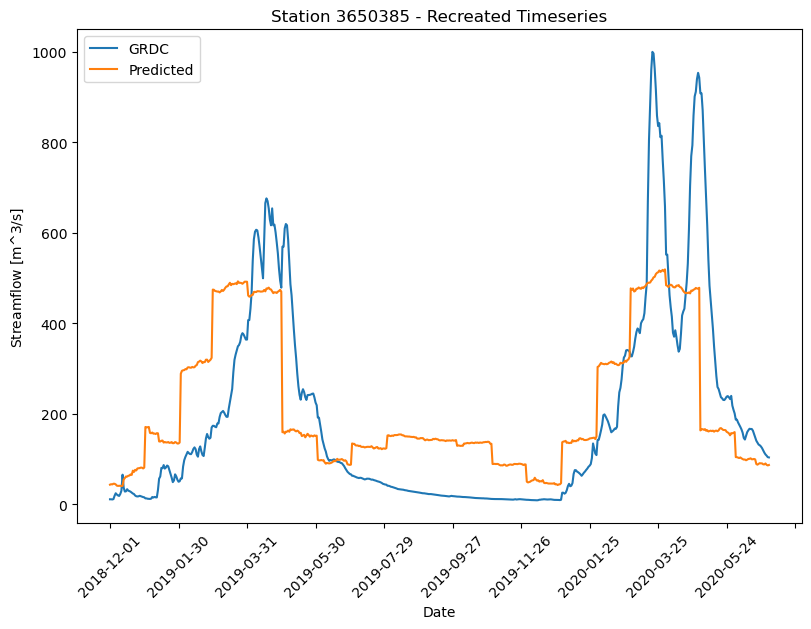

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


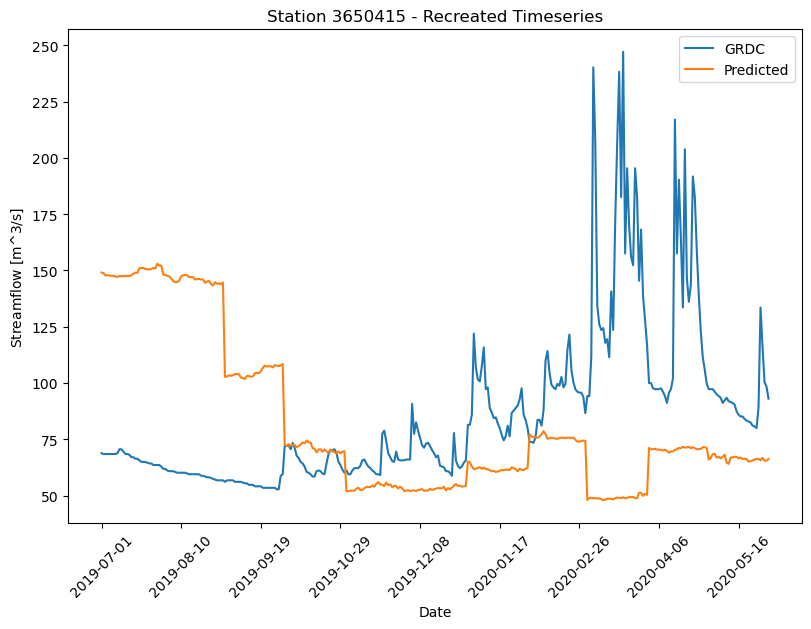

In [38]:
for i in range(300, 311):

    test_station_num = int(station_no[i])
    test_station_info = total_df[total_df['grdc_no'] == test_station_num]

    # True Q values (unscaled)
    targets = test_station_info['Q'].to_numpy()
    targets = scaler_y.transform(
        targets.reshape(-1, 1)
    ).flatten()

    # Input features
    test_X = test_station_info.drop([
        'Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
        'altitude', 'Q', 'SWE','r2'
    ], axis=1)

    # Scale inputs with the scaler fitted on TRAINING X
    test_X_scaled = scaler_X.transform(test_X)

    # Predict
    test_pred_ts = model.predict(test_X_scaled).flatten()

    # Inverse-transform y using the scaler fitted on TRAINING y
    test_pred_ts_unscaled = scaler_y.inverse_transform(
        test_pred_ts.reshape(-1, 1)
    ).flatten()

    targets_ts_unscaled = scaler_y.inverse_transform(
        targets.reshape(-1, 1)
    ).flatten()

    # # Compute NSE
    # nse_value = nse(test_pred, targets)
    # print(f"Station {test_station_num} NSE:", nse_value)

    # Plot
    plt.figure(figsize=(8,6))
    plt.plot(test_station_info['Date'], targets_ts_unscaled, label='GRDC')
    plt.plot(test_station_info['Date'], test_pred_ts_unscaled, label='Predicted')

    # plt.xticks(rotation=45)
    # ax = plt.gca()
    import matplotlib.ticker as ticker

    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))   # ~8 x-ticks max
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.legend()
    plt.title(f'Station {test_station_num} - Recreated Timeseries')
    plt.xlabel('Date')
    plt.ylabel('Streamflow [m^$3$/s]')
    plt.savefig(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/TIMESERIES/DAILY_PREDICTED/{test_station_num}.png')
    plt.show()

## Save Model Architecture and Analysis

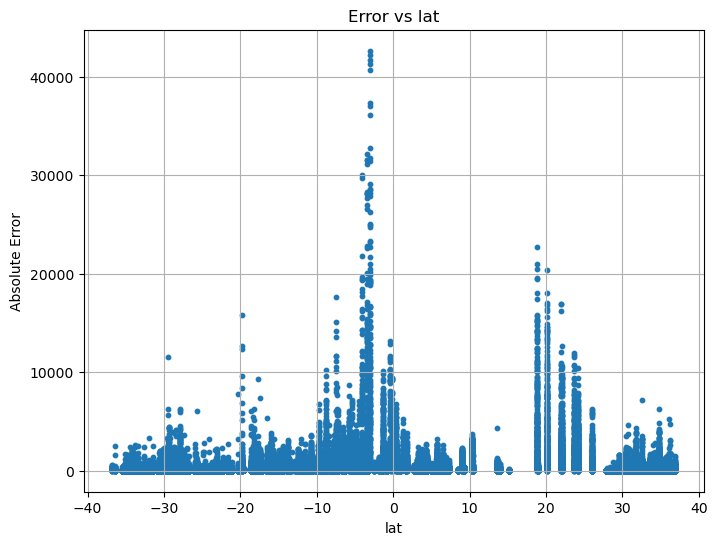

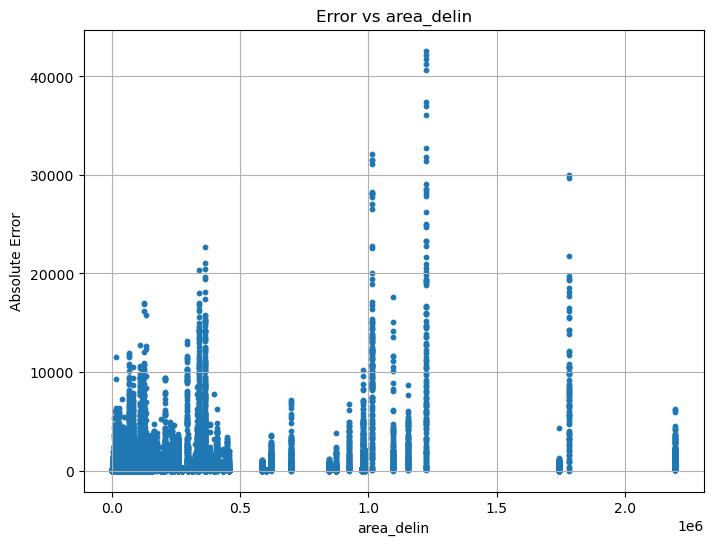

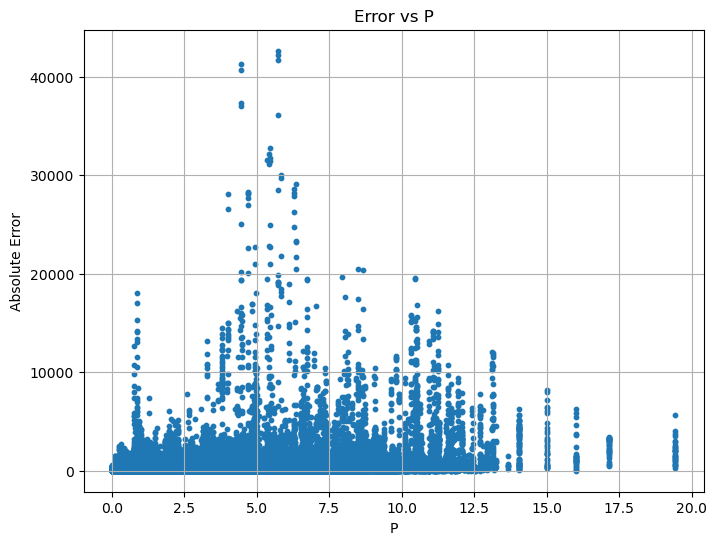

In [47]:
def plot_feature_vs_error(X_test, scaler_X, errors, col_index, col_name):
    X_unscaled = scaler_X.inverse_transform(X_test)
    feature = X_unscaled[:, col_index]

    plt.figure(figsize=(8,6))
    plt.scatter(feature, errors, s=10)
    plt.xlabel(col_name)
    plt.ylabel("Absolute Error")
    plt.title(f"Error vs {col_name}")
    plt.grid(True)
    plt.show()

errors = np.abs(y_pred - y_test_unscaled).reshape(-1)

plot_feature_vs_error(X_test, scaler_X, errors, 0, "lat")
plot_feature_vs_error(X_test, scaler_X, errors, 1, "area_delin")
plot_feature_vs_error(X_test, scaler_X, errors, 3, "P")


In [48]:
# # !pip install shap
# import shap

# explainer = shap.Explainer(model.predict, X_test)
# shap_values = explainer.shap_values(X_test)

import numpy as np

# choose N points to explain
N = 500  
idx = np.random.choice(len(X_test), size=N, replace=False)

X_test_subset = X_test[idx]

explainer = shap.Explainer(model.predict, X_test_subset)
shap_values = explainer(X_test_subset)

205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
211/211 ━━━━━━

PermutationExplainer explainer:   1%|          | 5/500 [00:00<?, ?it/s]

198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:   1%|▏         | 7/500 [00:14<10:07,  1.23s/it]

218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


...

PermutationExplainer explainer: 100%|█████████▉| 499/500 [20:08<00:02,  2.22s/it]

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


PermutationExplainer explainer: 100%|██████████| 500/500 [20:10<00:00,  2.19s/it]

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


PermutationExplainer explainer: 501it [20:12,  2.44s/it]                         


/tmp/ipykernel_3297350/2536394227.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset,feature_names=shap_features)


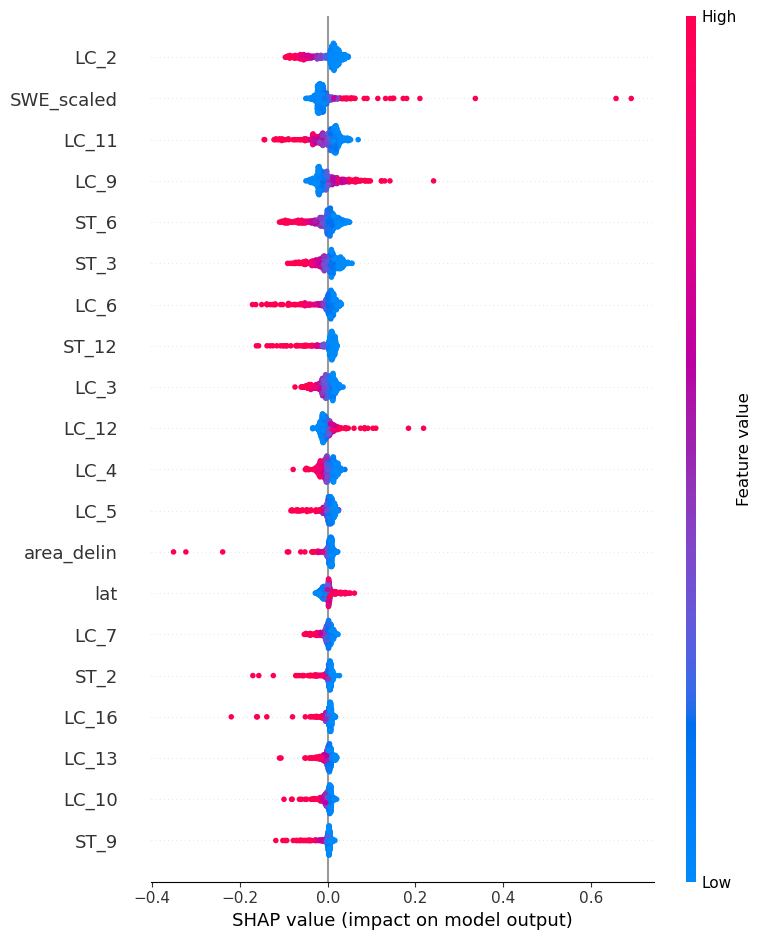

In [51]:
# shap_features = ['Surface Water Extent', 'Basin Area', 'Latitude', 'Avg Slope', 'Max Slope', 'Precipitation', 'LC Class 1',
#                 'LC Class 2','LC Class 3','LC Class 4','LC Class 5','LC Class 6','LC Class 7','LC Class 8','LC Class 9',
#                 'LC Class 10','LC Class 11','LC Class 12','LC Class 13','LC Class 14','LC Class 15','LC Class 16','LC Class 17',
#                 'LC Class 18','LC Class 19','LC Class 20','ST Class 1','ST Class 2','ST Class 3','ST Class 4','ST Class 5',
#                 'ST Class 6','ST Class 7','ST Class 8','ST Class 9','ST Class 10','ST Class 11','ST Class 12','ST Class 13',
#                  'ST Class 14','ST Class 15','ST Class 16']
shap_features = ['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 
                 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9', 'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 
                 'LC_16', 'LC_17', 'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5', 'ST_6', 
                 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13', 'ST_14', 'ST_15', 'ST_16']
shap.summary_plot(shap_values, X_test_subset,feature_names=shap_features)

In [50]:
# print("X_test:", X_test.shape)
# print("shap_values:", np.array(shap_values).shape)

X_test: (168954, 42)
shap_values: (500, 1)


/tmp/ipykernel_3297350/833960656.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, feature_names=shap_features,plot_type="bar")


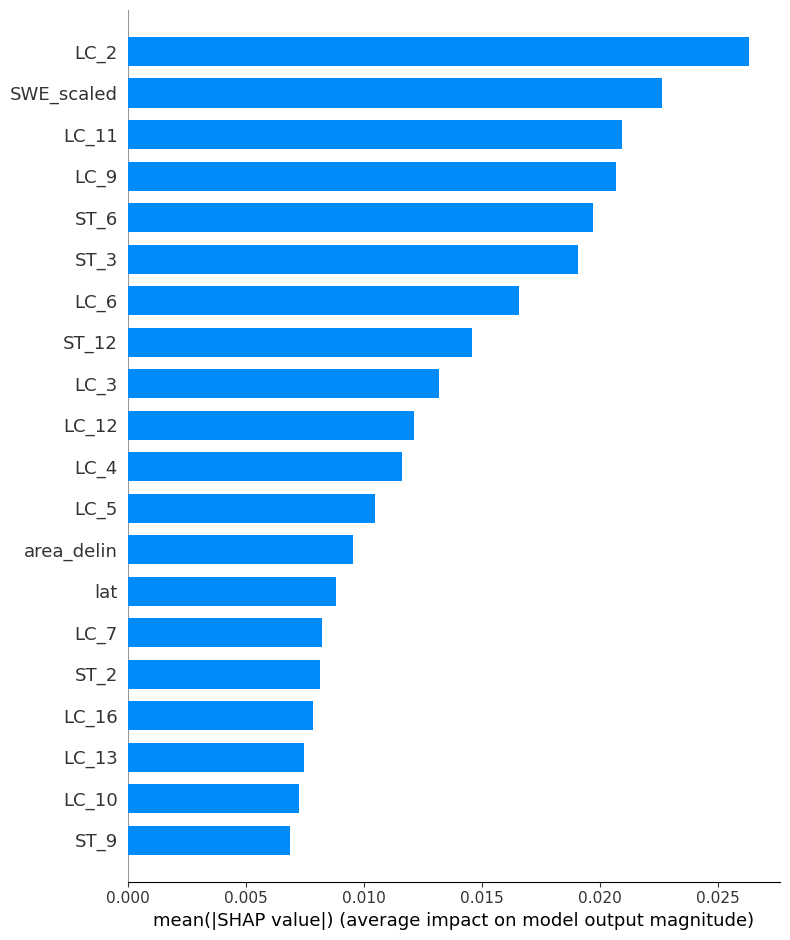

In [52]:
shap.summary_plot(shap_values, X_test_subset, feature_names=shap_features,plot_type="bar")

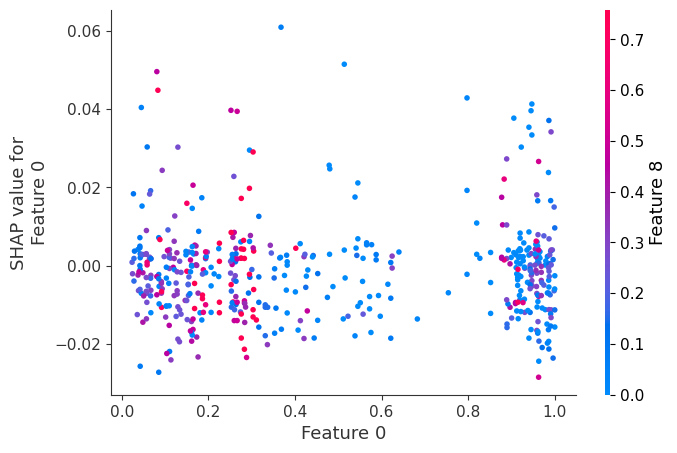

In [56]:
# shap.dependence_plot("Feature 0", shap_values, X_test_subset)
# Fix shape
shap_vals = shap_values.values
if shap_vals.ndim == 3:
    shap_vals = shap_vals[..., 0]

shap.dependence_plot("Feature 0", shap_vals, X_test_subset)


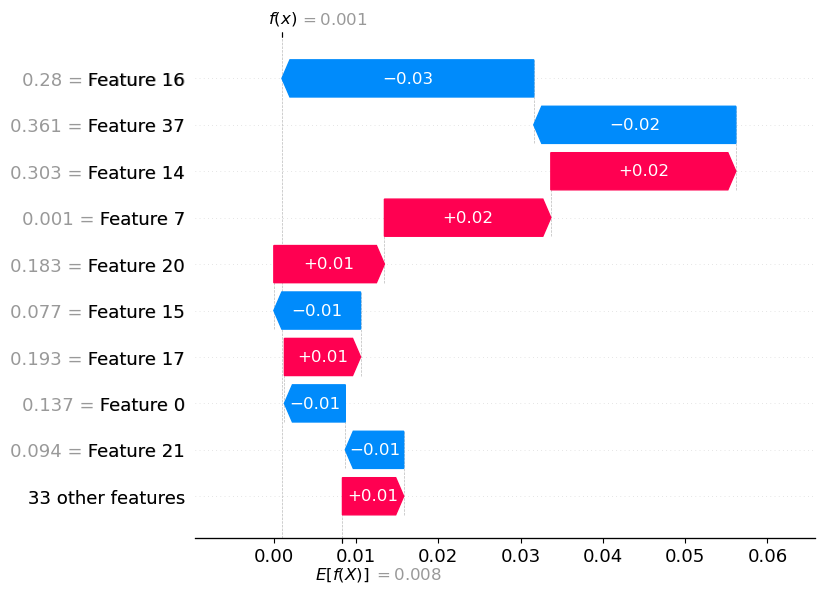

In [64]:
# shap.waterfall_plot(shap_values,X_test_subset)

# pick a random sample index
i = np.random.randint(0, len(X_test_subset))

# pass the single Explanation for that sample
shap.waterfall_plot(shap_values[i])

In [ ]:
# # zoomed in plot
# # y_pred = model.predict(X_test)
# # # y_pred = np.expm1(y_pred)

# # Step 2: Create the scatter plot
# plt.figure(figsize=(6,6))
# plt.scatter(y_test*max(y), y_pred*max(y), alpha=0.5, label="Predicted vs Actual")
# plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 (y=x)', linewidth=2)
# plt.fill_between(y_err, y_err-error, y_err+error,alpha=0.2,label='75th percentile')

# # Step 3: Add labels, title, and legend
# plt.title("Streamflow Actual vs Predicted Values")
# plt.xlabel("Actual Values [m${^3}$/s]")
# plt.ylabel("Predicted Values [m${^3}$/s]")
# plt.legend()
# plt.xlim(0,25000)
# plt.ylim(0,25000)
# plt.grid(alpha=0.5)

# # Step 4: Show the plot
# plt.show()

/tmp/ipykernel_3297350/1895997489.py:2: RuntimeWarning: divide by zero encountered in log
  xlog = np.log(y_test_unscaled)
/tmp/ipykernel_3297350/1895997489.py:3: RuntimeWarning: invalid value encountered in log
  ylog = np.log(y_pred)


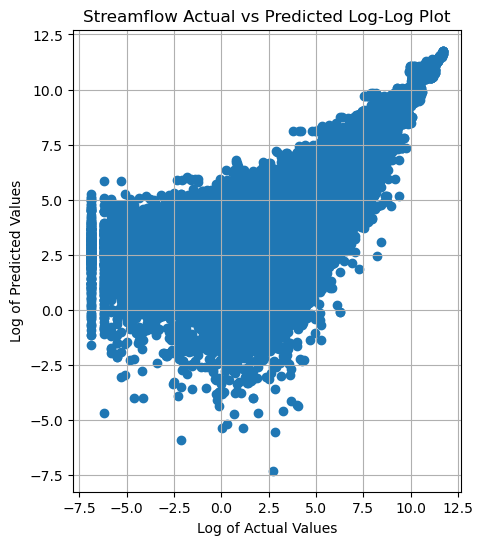

In [41]:
# Create the log-log plot
xlog = np.log(y_test_unscaled)
ylog = np.log(y_pred)

plt.figure(figsize=(5,6))
plt.scatter(xlog, ylog)
# Add labels and title
plt.xlabel('Log of Actual Values')
plt.ylabel('Log of Predicted Values')
plt.title('Streamflow Actual vs Predicted Log-Log Plot')

# Customize gridlines (optional)
plt.grid(True, which="both", ls="-")

# Show the plot
plt.show()

In [ ]:
# # Extract loss and validation loss from the training history
# test_values = y_test*max(y)
# pred_values = y_pred*max(y)

# test_values = np.ravel(test_values)
# pred_values = np.ravel(pred_values)

# # Create a new DataFrame
# pred_df = pd.DataFrame({
#     'Test Values': test_values,
#     'Predicted Values': pred_values
# })

# file_path =  '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/test_vs_pred_values.csv'

# # Export to a CSV file
# # pred_df.to_csv(file_path, index=False)

# from sklearn.metrics import r2_score

# # Assuming test_values and pred_values are 1D arrays or lists
# r_squared = r2_score(test_values, pred_values)
# print(f"R-squared value: {r_squared}")


Mean Squared Error (MSE): 817506.271330897


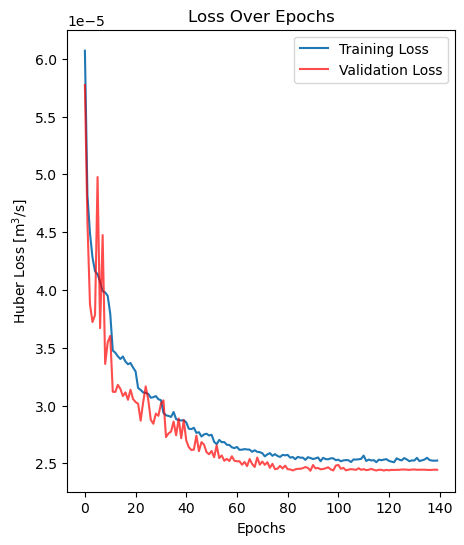

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Compute MSE
mse = mean_squared_error(y_test_unscaled, y_pred)
print("Mean Squared Error (MSE):", mse)

# Extract loss and validation loss from the training history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Create a new DataFrame
loss_df = pd.DataFrame({
    'Epoch': range(1, len(training_loss) + 1),  # Adding epoch numbers
    'Training Loss': training_loss,
    'Validation Loss': validation_loss
})

file_path =  '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/CNN/training_validation_losses.csv'

# Export to a CSV file
# loss_df.to_csv(file_path, index=False)

5280/5280 ━━━━━━━━━━━━━━━━━━━━ 5s 923us/step


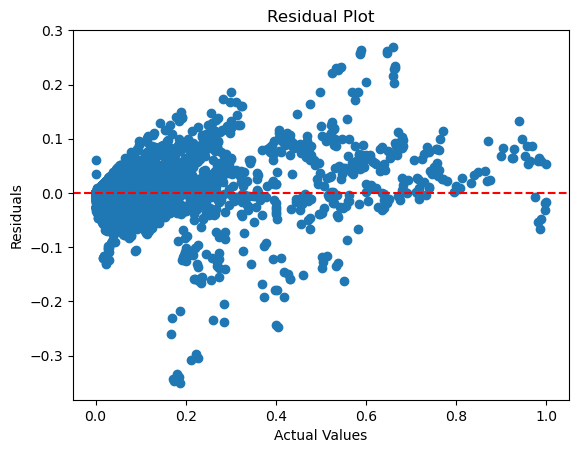

In [43]:
import matplotlib.pyplot as plt

residuals = y_test - model.predict(X_test)
plt.scatter(y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

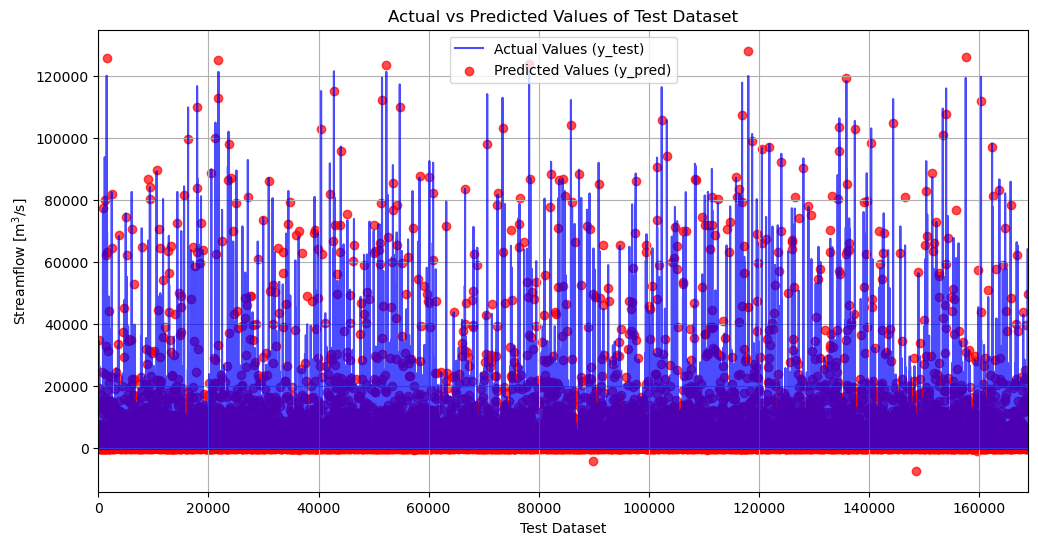

In [67]:
# Plot y_test and y_pred as a time series
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y_test)), y_test_unscaled, label="Actual Values (y_test)", color="blue", alpha=0.7)
plt.scatter(np.arange(len(y_pred)), y_pred, label="Predicted Values (y_pred)", color="red", alpha=0.7)
plt.title("Actual vs Predicted Values of Test Dataset")
plt.xlabel("Test Dataset")
plt.ylabel("Streamflow [m${^3}$/s]")
plt.xlim(0,len(y_test))
plt.legend()
plt.grid(True)
plt.show()

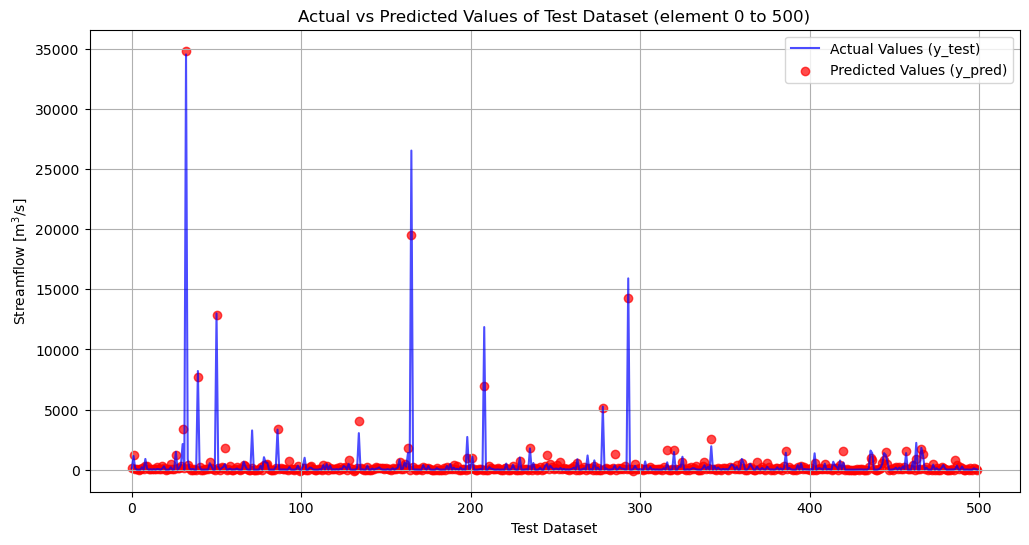

In [68]:
# Plot y_test and y_pred as a time series
plt.figure(figsize=(12, 6))
plt.plot((np.arange(len(y_test)))[0:500], (y_test_unscaled)[0:500], label="Actual Values (y_test)", color="blue", alpha=0.7)
plt.scatter((np.arange(len(y_pred)))[0:500], (y_pred)[0:500], label="Predicted Values (y_pred)", color="red", alpha=0.7)

# Add titles and labels
plt.title("Actual vs Predicted Values of Test Dataset (element 0 to 500)")
plt.xlabel("Test Dataset")
plt.ylabel("Streamflow [m${^3}$/s]")
# plt.xlim(0,len(y_test))
plt.legend()
plt.grid(True)
plt.show()

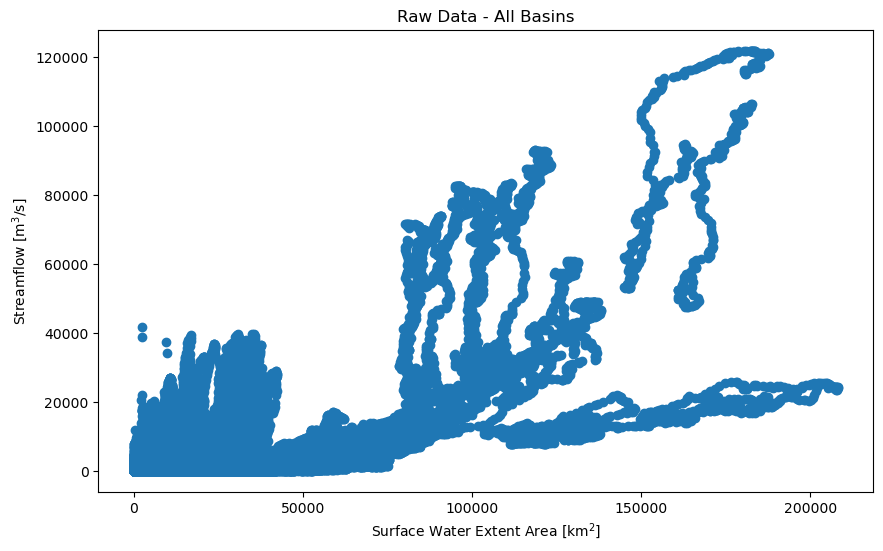

In [72]:
plt.figure(figsize=(10,6))
plt.scatter(total_df['SWE_scaled'],total_df['Q'])
plt.title('Raw Data - All Basins')
plt.xlabel('Surface Water Extent Area [km${^2}$]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(area,q,color='g')
plt.title('Raw Data - All Basins')
plt.xlabel('Total Basin Area [km${^2}$]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(lat*np.pi/180,q,color='r')
plt.title('Raw Data - All Basins')
plt.xlabel('Latitude [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(avg_slope,q,color='purple')
plt.title('Raw Data - All Basins')
plt.xlabel('Slope [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(max_slope,q,color='brown')
plt.title('Raw Data - All Basins')
plt.xlabel('Slope [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(precip/1e6,q,color='blue')
plt.title('Raw Data - All Basins')
plt.xlabel('Precip []')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
lc_class = lc_types.idxmax(axis=1)
plt.scatter(lc_class,q,color='orange')
plt.title('Raw Data - All Basins')
plt.xlabel('Land Cover Type')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
soil_class = soil_types.idxmax(axis=1)

plt.scatter(soil_class,q,color='darkorange')
plt.title('Raw Data - All Basins')
plt.xlabel('Soil Texture')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
grouped = total_df.groupby('Area')['Q'].mean()

# Extract unique areas and their corresponding average Q values
area_unique = grouped.index
q_avg = grouped.values

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(area_unique, q_avg, color='g')
plt.xlabel('Total Basin Area')
plt.ylabel('Average Streamflow')
plt.title('Average Streamflow vs Total Basin Area')
plt.grid(True)
plt.show()

In [ ]:
grouped = total_df.groupby('Latitude')['Q'].mean()

# Extract unique areas and their corresponding average Q values
lat_unique = grouped.index
q_avg = grouped.values

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(lat_unique, q_avg,color='red')
plt.xlabel('Latitude')
plt.ylabel('Average Streamflow')e
plt.title('Average Streamflow vs Basin Latitude')
plt.grid(True)
plt.show()

In [ ]:
filename = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/FNN/rnn_plot.png'
# Ensure the directory exists
os.makedirs(os.path.dirname(filename), exist_ok=True)
from tensorflow.keras.utils import plot_model

# Plot and save the model
plot_model(model,show_dtype=True, show_layer_names=True, show_shapes=True,  to_file=filename)

# # from IPython.display import Image
# # Image(filename)